<a href="https://colab.research.google.com/github/OrangBiasa29/Deep-Learning/blob/main/Tugas2/Assignment_2_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 — Learning Strategy: MNIST

Task:
1. L1 Regularization
2. L2 Regularization
3. Dropout
4. Early Stopping
5. L1 Regularization + Dropout


In [1]:
# Load data
import keras
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1, 28,28,1)
X_test = X_test.reshape(-1, 28,28,1)

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

X_train /= 255
X_test /= 255

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [2]:
# Define Model
from keras.models import Sequential
from keras.layers import Flatten, Dense

model1 = Sequential()
model1.add(Flatten())
model1.add(Dense(64,activation='relu'))
model1.add(Dense(10,activation='softmax'))

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Compile Model, Fit Model, Save Model, and Evaluate Model
model1.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['acc'])
history = model1.fit(X_train,y_train,epochs=10,batch_size=100,validation_data=(X_test,y_test))
model1.save('my_model1.h5')
model1.evaluate(X_test,y_test)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.8897 - loss: 0.3989 - val_acc: 0.9349 - val_loss: 0.2238
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9460 - loss: 0.1883 - val_acc: 0.9549 - val_loss: 0.1627
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9596 - loss: 0.1414 - val_acc: 0.9622 - val_loss: 0.1290
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9675 - loss: 0.1125 - val_acc: 0.9664 - val_loss: 0.1134
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9727 - loss: 0.0938 - val_acc: 0.9690 - val_loss: 0.1039
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9768 - loss: 0.0795 - val_acc: 0.9704 - val_loss: 0.1006
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9794 - loss: 0.0693 - val_acc: 0.9720 - val_loss: 0.0951
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9821 - loss: 0.0617 - val_acc: 0.9723 - val_loss: 0.0943
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9741 - loss: 0.0875


[0.0875309407711029, 0.9740999937057495]

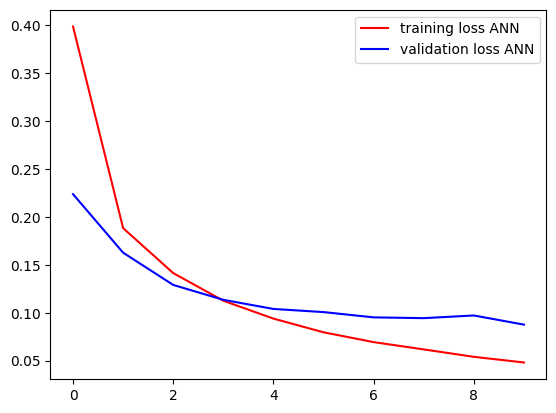

In [4]:
# Visualize Model Evaluation
import matplotlib.pyplot as plt

epochs = range(10)
loss1 = history.history['loss']
val_loss1 = history.history['val_loss']

plt.plot(epochs,loss1,'r',label='training loss ANN')
plt.plot(epochs,val_loss1,'b',label='validation loss ANN')
plt.legend()


In [5]:
# Load Model and Prediction
import numpy as np
from keras.models import load_model

model_simpan = load_model('my_model1.h5')
pred = model_simpan.predict(X_test)

print('label actual:',np.argmax(y_test[30]))
print('label prediction:',np.argmax(pred[30]))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
label actual: 3
label prediction: 3


## Scenario 2(a) — L1 Regularization

Chosen L1 rate: `0.0001`


In [6]:
from keras.regularizers import l1

model_l1 = Sequential()
model_l1.add(Flatten())
model_l1.add(Dense(64,activation='relu',kernel_regularizer=l1(0.0001)))
model_l1.add(Dense(10,activation='softmax'))

model_l1.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['acc'])

history_l1 = model_l1.fit(
    X_train,y_train,
    epochs=10,
    batch_size=100,
    validation_data=(X_test,y_test)
)

model_l1.summary()

loss_l1, accuracy_l1 = model_l1.evaluate(X_test,y_test)
print('Akurasi Testing L1:', accuracy_l1)


Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8914 - loss: 0.5274 - val_acc: 0.9316 - val_loss: 0.3543
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9417 - loss: 0.3140 - val_acc: 0.9525 - val_loss: 0.2753
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9527 - loss: 0.2639 - val_acc: 0.9589 - val_loss: 0.2420
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9605 - loss: 0.2350 - val_acc: 0.9638 - val_loss: 0.2224
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9640 - loss: 0.2150 - val_acc: 0.9639 - val_loss: 0.2096
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9680 - loss: 0.2018 - val_acc: 0.9675 - val_loss: 0.2035
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9697 - loss: 0.1909 - val_acc: 0.9684 - val_loss: 0.1937
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9714 - loss: 0.1836 - val_acc: 0.9706 - val_loss: 0.1870
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9701 - loss: 0.1788
Akurasi Testing L1: 0.9700999855995178


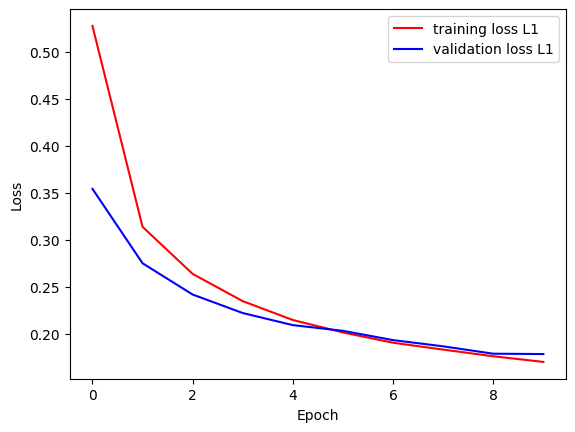

In [7]:
epochs_l1 = range(10)
loss_l1_history = history_l1.history['loss']
val_loss_l1_history = history_l1.history['val_loss']

plt.figure()
plt.plot(epochs_l1,loss_l1_history,'r',label='training loss L1')
plt.plot(epochs_l1,val_loss_l1_history,'b',label='validation loss L1')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


## Scenario 2(b) — L2 Regularization

Chosen L2 rate: `0.0001`


In [8]:
from keras.regularizers import l2

model_l2 = Sequential()
model_l2.add(Flatten())
model_l2.add(Dense(64,activation='relu',kernel_regularizer=l2(0.0001)))
model_l2.add(Dense(10,activation='softmax'))

model_l2.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['acc'])

history_l2 = model_l2.fit(
    X_train,y_train,
    epochs=10,
    batch_size=100,
    validation_data=(X_test,y_test)
)

model_l2.summary()

loss_l2, accuracy_l2 = model_l2.evaluate(X_test,y_test)
print('Akurasi Testing L2:', accuracy_l2)


Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8965 - loss: 0.4001 - val_acc: 0.9386 - val_loss: 0.2255
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9469 - loss: 0.2021 - val_acc: 0.9534 - val_loss: 0.1776
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9592 - loss: 0.1599 - val_acc: 0.9623 - val_loss: 0.1483
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9655 - loss: 0.1378 - val_acc: 0.9640 - val_loss: 0.1365
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9715 - loss: 0.1226 - val_acc: 0.9678 - val_loss: 0.1281
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9756 - loss: 0.1099 - val_acc: 0.9712 - val_loss: 0.1228
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9776 - loss: 0.1024 - val_acc: 0.9720 - val_loss: 0.1200
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9797 - loss: 0.0954 - val_acc: 0.9717 - val_loss: 0.1141
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9741 - loss: 0.1079
Akurasi Testing L2: 0.9740999937057495


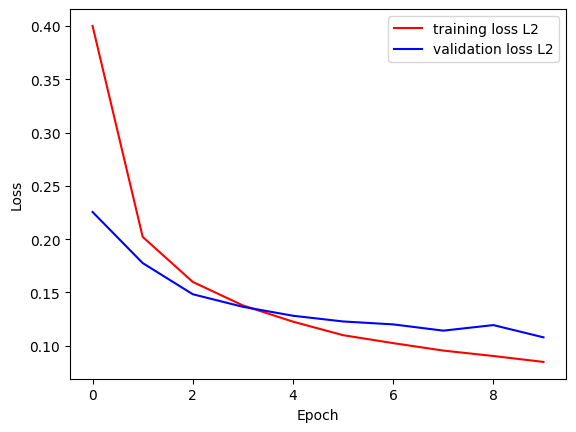

In [9]:
epochs_l2 = range(10)
loss_l2_history = history_l2.history['loss']
val_loss_l2_history = history_l2.history['val_loss']

plt.figure()
plt.plot(epochs_l2,loss_l2_history,'r',label='training loss L2')
plt.plot(epochs_l2,val_loss_l2_history,'b',label='validation loss L2')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


## Scenario 2(c) — Dropout

Chosen Dropout rate: `0.3`


In [10]:
from keras.layers import Dropout

model_dropout = Sequential()
model_dropout.add(Flatten())
model_dropout.add(Dense(64,activation='relu'))
model_dropout.add(Dropout(0.3))
model_dropout.add(Dense(10,activation='softmax'))

model_dropout.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['acc'])

history_dropout = model_dropout.fit(
    X_train,y_train,
    epochs=10,
    batch_size=100,
    validation_data=(X_test,y_test)
)

model_dropout.summary()

loss_dropout, accuracy_dropout = model_dropout.evaluate(X_test,y_test)
print('Akurasi Testing Dropout:', accuracy_dropout)


Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.8524 - loss: 0.5067 - val_acc: 0.9296 - val_loss: 0.2356
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9210 - loss: 0.2753 - val_acc: 0.9477 - val_loss: 0.1704
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9334 - loss: 0.2270 - val_acc: 0.9556 - val_loss: 0.1462
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9421 - loss: 0.1965 - val_acc: 0.9604 - val_loss: 0.1328
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9477 - loss: 0.1799 - val_acc: 0.9632 - val_loss: 0.1207
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9519 - loss: 0.1643 - val_acc: 0.9684 - val_loss: 0.1105
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9546 - loss: 0.1501 - val_acc: 0.9675 - val_loss: 0.1065
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9567 - loss: 0.1417 - val_acc: 0.9698 - val_loss: 0.0989
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - ac

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (100, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9711 - loss: 0.0933
Akurasi Testing Dropout: 0.9710999727249146


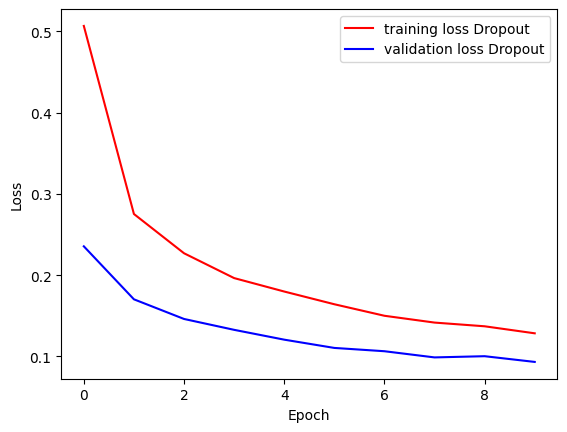

In [11]:
epochs_dropout = range(10)
loss_dropout_history = history_dropout.history['loss']
val_loss_dropout_history = history_dropout.history['val_loss']

plt.figure()
plt.plot(epochs_dropout,loss_dropout_history,'r',label='training loss Dropout')
plt.plot(epochs_dropout,val_loss_dropout_history,'b',label='validation loss Dropout')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


## Scenario 2(d) — Early Stopping

Parameter yang digunakan:
- `monitor='val_loss'`
- `patience=2`
- `restore_best_weights=True`


In [12]:
from keras.callbacks import EarlyStopping

model_early = Sequential()
model_early.add(Flatten())
model_early.add(Dense(64,activation='relu'))
model_early.add(Dense(10,activation='softmax'))

model_early.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['acc'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_early = model_early.fit(
    X_train,y_train,
    epochs=10,
    batch_size=100,
    validation_data=(X_test,y_test),
    callbacks=[early_stopping]
)

model_early.summary()

loss_early, accuracy_early = model_early.evaluate(X_test,y_test)
print('Akurasi Testing Early Stopping:', accuracy_early)
print('Jumlah epoch aktual:', len(history_early.history['loss']))


Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8914 - loss: 0.4023 - val_acc: 0.9372 - val_loss: 0.2234
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9452 - loss: 0.1953 - val_acc: 0.9537 - val_loss: 0.1627
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9585 - loss: 0.1450 - val_acc: 0.9624 - val_loss: 0.1325
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9661 - loss: 0.1173 - val_acc: 0.9670 - val_loss: 0.1158
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9724 - loss: 0.0978 - val_acc: 0.9684 - val_loss: 0.1076
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9762 - loss: 0.0841 - val_acc: 0.9714 - val_loss: 0.0961
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9793 - loss: 0.0737 - val_acc: 0.9749 - val_loss: 0.0876
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9809 - loss: 0.0659 - val_acc: 0.9736 - val_loss: 0.0890
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9756 - loss: 0.0827
Akurasi Testing Early Stopping: 0.975600004196167
Jumlah epoch aktual: 10


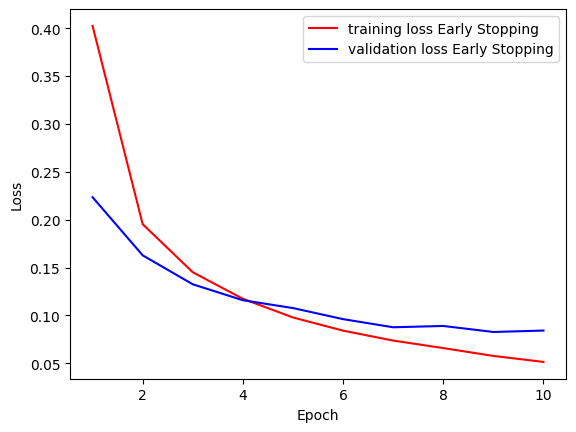

In [13]:
epochs_early = range(1, len(history_early.history['loss']) + 1)
loss_early_history = history_early.history['loss']
val_loss_early_history = history_early.history['val_loss']

plt.figure()
plt.plot(epochs_early,loss_early_history,'r',label='training loss Early Stopping')
plt.plot(epochs_early,val_loss_early_history,'b',label='validation loss Early Stopping')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


## Scenario 2(e) — L1 Regularization + Dropout

Chosen L1 rate: `0.0001`  
Chosen Dropout rate: `0.3`


In [14]:
model_l1_dropout = Sequential()
model_l1_dropout.add(Flatten())
model_l1_dropout.add(Dense(64,activation='relu',kernel_regularizer=l1(0.0001)))
model_l1_dropout.add(Dropout(0.3))
model_l1_dropout.add(Dense(10,activation='softmax'))

model_l1_dropout.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['acc'])

history_l1_dropout = model_l1_dropout.fit(
    X_train,y_train,
    epochs=10,
    batch_size=100,
    validation_data=(X_test,y_test)
)

model_l1_dropout.summary()

loss_l1_dropout, accuracy_l1_dropout = model_l1_dropout.evaluate(X_test,y_test)
print('Akurasi Testing L1 + Dropout:', accuracy_l1_dropout)


Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.8504 - loss: 0.6468 - val_acc: 0.9316 - val_loss: 0.3602
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9170 - loss: 0.4020 - val_acc: 0.9465 - val_loss: 0.2997
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9297 - loss: 0.3537 - val_acc: 0.9520 - val_loss: 0.2693
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9371 - loss: 0.3243 - val_acc: 0.9560 - val_loss: 0.2538
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9417 - loss: 0.3046 - val_acc: 0.9615 - val_loss: 0.2341
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9441 - loss: 0.2922 - val_acc: 0.9650 - val_loss: 0.2236
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9466 - loss: 0.2773 - val_acc: 0.9663 - val_loss: 0.2143
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9494 - loss: 0.2705 - val_acc: 0.9682 - val_loss: 0.2069
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (100, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9692 - loss: 0.2004
Akurasi Testing L1 + Dropout: 0.9692000150680542


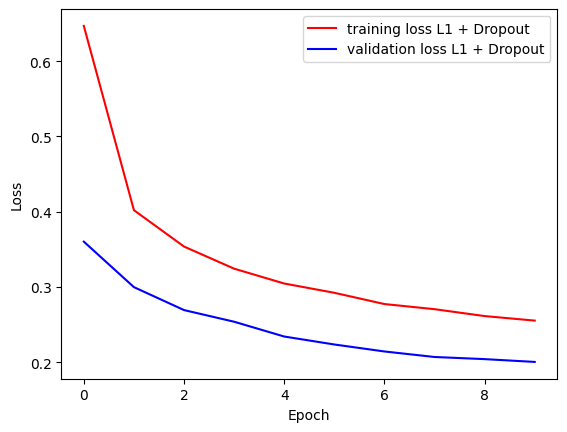

In [15]:
epochs_l1_dropout = range(10)
loss_l1_dropout_history = history_l1_dropout.history['loss']
val_loss_l1_dropout_history = history_l1_dropout.history['val_loss']

plt.figure()
plt.plot(epochs_l1_dropout,loss_l1_dropout_history,'r',label='training loss L1 + Dropout')
plt.plot(epochs_l1_dropout,val_loss_l1_dropout_history,'b',label='validation loss L1 + Dropout')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


## Rekap hasil


In [16]:
import pandas as pd

results = pd.DataFrame({
    'Scenario': [
        'Baseline',
        'L1',
        'L2',
        'Dropout',
        'Early Stopping',
        'L1 + Dropout'
    ],
    'Test Accuracy': [
        model1.evaluate(X_test,y_test,verbose=0)[1],
        accuracy_l1,
        accuracy_l2,
        accuracy_dropout,
        accuracy_early,
        accuracy_l1_dropout
    ]
})

results


,Scenario,Test Accuracy
0,Baseline,0.9741
1,L1,0.9701
2,L2,0.9741
3,Dropout,0.9711
4,Early Stopping,0.9756
5,L1 + Dropout,0.9692
